# Brownian Bridge Path Construction


[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/QMCSoftware/QMCSoftware/blob/develop/demos/brownian_bridge.ipynb)

`BrownianMotion` supports multiple path construction methods via the `decomp_type` parameter, including `'PCA'` and `'Cholesky'`. This notebook introduces `'BrownianBridge'`, which samples time points by conditioning on the two nearest time values that have already been sampled. The default order follows the van der Corput sequence, with the first term replaced by the terminal time and the full sequence scaled by the provided `t_final`. This ensures that each QMC dimension is used in decreasing order of variance. A custom order can also be provided through `monitoring_times`. 

In [22]:
from qmcpy import *
import numpy as np
from matplotlib import pyplot
%matplotlib inline
pyplot.rc('font', size=14)
pyplot.rc('axes', titlesize=14)
pyplot.rc('axes', labelsize=14)
pyplot.rc('xtick', labelsize=14)
pyplot.rc('ytick', labelsize=14)
pyplot.rc('legend', fontsize=14)
pyplot.rc('figure', titlesize=14)

In [23]:
vdc = DigitalNetB2(1,randomize=False,order='Gray')(6)
vdc

array([[0.   ],
       [0.5  ],
       [0.75 ],
       [0.25 ],
       [0.375],
       [0.875]])

## Basic Usage


The `decomp_type` parameter is documented in the `BrownianMotion` constructor:

In [5]:
help(BrownianMotion.__init__)

Help on function __init__ in module qmcpy.true_measure.brownian_motion:

__init__(
    self,
    sampler,
    t_final=1,
    initial_value=0,
    drift=0,
    diffusion=1,
    decomp_type='PCA',
    lazy_decomp=True,
    monitoring_times=None
)
    Args:
        sampler (Union[AbstractDiscreteDistribution, AbstractTrueMeasure]): Either

            - a discrete distribution from which to transform samples, or
            - a true measure by which to compose a transform.
        t_final (float): End time.
        initial_value (float): Initial value $B_0$.
        drift (int): Drift $\gamma$.
        diffusion (int): Diffusion $\sigma^2$.
        decomp_type (str): Method for decomposition for covariance matrix. Options include

            - `'PCA'` for principal component analysis,
            - `'Cholesky'` for cholesky decomposition, or
            - `'BrownianBridge'` for brownian bridge construction.
        lazy_decomp (bool): If True, defer expensive matrix decomposition until n

In [6]:
l4 = Lattice(4, seed=7)
bm = BrownianMotion(l4, decomp_type='BrownianBridge')
bm, l4(1)

(BrownianMotion (AbstractTrueMeasure)
     time_vec        [0.25 0.5  0.75 1.  ]
     drift           0
     mean            [0. 0. 0. 0.]
     covariance      [[0.25 0.25 0.25 0.25]
                      [0.25 0.5  0.5  0.5 ]
                      [0.25 0.5  0.75 0.75]
                      [0.25 0.5  0.75 1.  ]]
     decomp_type     BROWNIANBRIDGE,
 array([[0.04386058, 0.58727432, 0.3691824 , 0.65212985]]))

In [7]:
x4 = bm.gen_samples(4)
x4

array([[-0.48984474, -0.74350199, -1.08725591, -1.70754305],
       [ 0.084984  , -0.62378384, -0.62002968,  0.1101646 ],
       [-0.65738278, -0.4810274 , -0.59920835, -0.54214131],
       [ 0.55804662,  0.90160358,  1.31816823,  0.81988997]])

## Brownian Bridge Construction

Given a Brownian motion $W$ with $W(0) = 0$, the conditional distribution of an interior value given its two surrounding anchor points is

$$W(s) \;\Big|\; W(\ell),\, W(r) \;\sim\; \mathcal{N}(\mu,\, \sigma^2)$$

with $\ell$ and $r$ as the nearest sampled neighbors below and above $s$. The conditional mean and variance are

$$\mu = W(\ell) + \frac{s - \ell}{r - \ell}\big(W(r) - W(\ell)\big), \qquad \sigma^2 = \frac{(s - \ell)(r - s)}{r - \ell}.$$

Manipulating the mean equation, the result is

$$W(s_j) = a_j\,W(\ell_j) + b_j\,W(r_j) + w_j\,Z_j, \qquad Z_j \sim \mathcal{N}(0,1),$$

with coefficients $a_j$ and $b_j$ depending on which neighbors are available, which creates four cases:

| case | $a_j$ | $b_j$ | $w_j$ |
|------|-------|-------|-------|
| first point, no neighbor | $0$ | $0$ | $\sqrt{s_j}$ |
| left neighbor only | $1$ | $0$ | $\sqrt{s_j - \ell_j}$ |
| right neighbor only | $0$ | $s_j / r_j$ | $\sqrt{s_j (r_j - s_j) / r_j}$ |
| both neighbors | $\dfrac{r_j - s_j}{r_j - \ell_j}$ | $\dfrac{s_j - \ell_j}{r_j - \ell_j}$ | $\sqrt{\dfrac{(s_j - \ell_j)(r_j - s_j)}{r_j - \ell_j}}$ |

(Owen, equations 6.10 and 6.11, Algorithm 6.1)

### Non-Power-of-2 Dimensions

The same four cases apply regardless of $d$. However, a `ParameterWarning` is raised whenever $d$ is not a power of 2 since the resulting time grid is no longer split into equally spaced intervals for a van der Corput sequence.

## Covariance Factorization

`'PCA'` and `'Cholesky'` each produce a matrix $A$ with $AA^\top = \Sigma$, where $\Sigma_{ij} = \min(t_i, t_j)$ is the Brownian motion covariance, and build a path as $W = AZ$ for $Z \sim \mathcal{N}(0, I)$. PCA uses the eigendecomposition $\Sigma = P\Lambda P^\top$ and takes $A = P\Lambda^{1/2}P^\top$. Cholesky decomposition identifies a lower triangular matrix $L$ with $LL^\top = \Sigma$, and takes $A = L$.

The bridge produces the same factorization without factoring $\Sigma$. For $d = 4$, using the van der Corput sequence and sorting by increasing time,

$$W(\tfrac14) = \tfrac14 Z_1 + \tfrac14 Z_2 + \sqrt{\tfrac18}\, Z_3$$
$$W(\tfrac12) = \tfrac12 Z_1 + \tfrac12 Z_2$$
$$W(\tfrac34) = \tfrac34 Z_1 + \tfrac14 Z_2 + \sqrt{\tfrac18}\, Z_4$$
$$W(1) = Z_1$$

Where $A_{ij}$ is the coefficient of $Z_j$ in $W(t_i)$, a matrix $A$ is created that satisfies $AA^\top = \Sigma$ [[1](#ref1)].

## Path Construction for Increasing $d$

BrownianBridge paths for $d \in \{1, 2, 3, 4, 5, 6, 7, 8, 128\}$. For powers of 2 ($d = 4$ and $d = 8$), paths at shared time points are identical, meaning that the $d = 8$ paths are essentially a refinement of the $d = 4$ paths. Going from $d = 4$ to $d = 8$ simply inserts new points in between existing points. For non-powers of 2 ($d = 5, 6, 7$), the bisection adds time points at non-midpoint locations.

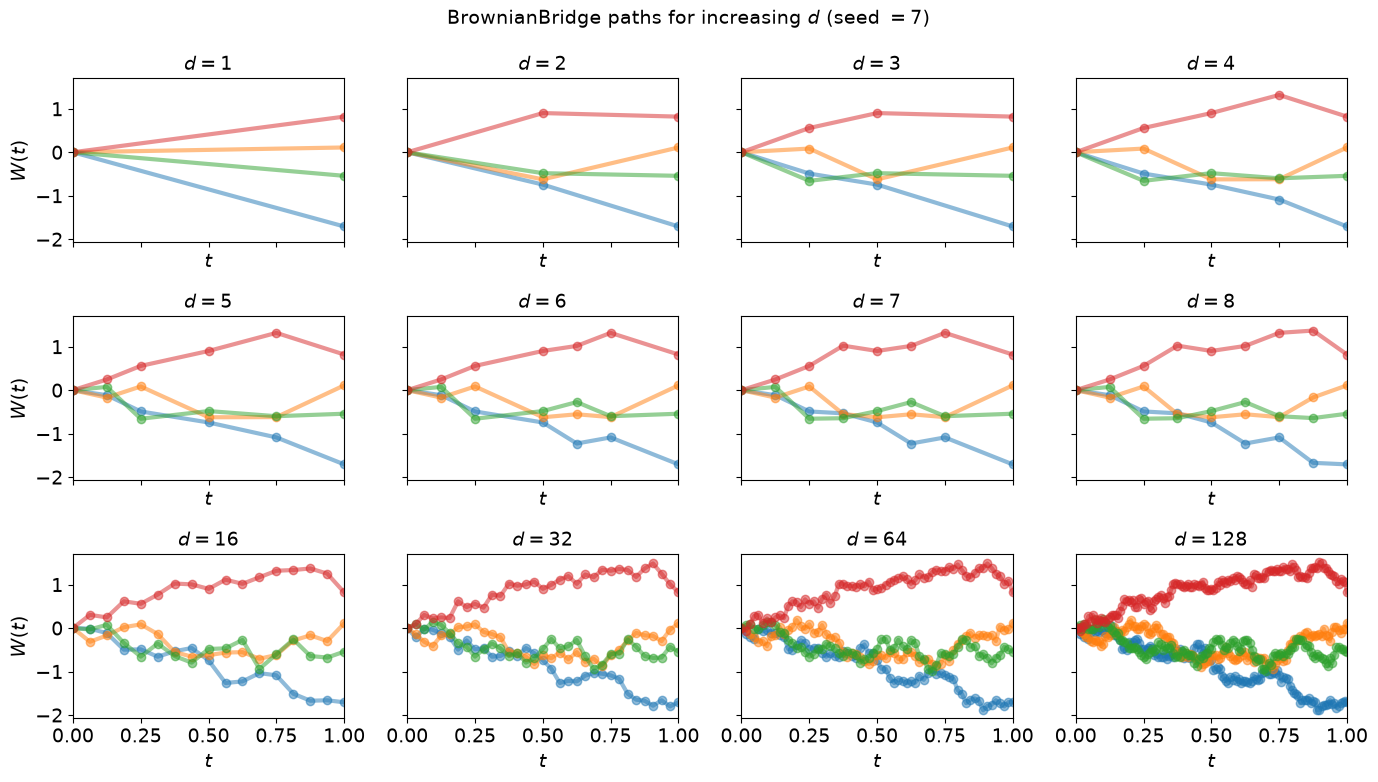

In [9]:
import warnings

dims = [1,2,3,4,5,6,7,8,16,32,64,128]
n = 4
t_final = 1.0
seed = 7

fig, axes = pyplot.subplots(3, 4, figsize=(14, 8), sharey=True, sharex=True)
axes_flat = axes.flatten()

for ax, d in zip(axes_flat, dims):
    # Pick the first d time points by index
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        bm_full = BrownianMotion(Lattice(d, seed=seed), t_final=t_final, decomp_type='BrownianBridge')
    paths = bm_full.gen_samples(n)
    paths_full = np.concat([np.zeros((n,1)),paths],axis=-1)
    times = np.concat([[0],bm_full.time_vec])
    ax.plot(times, paths_full.T, "-o",alpha=0.5, linewidth=3)
    ax.set_title(f'$d = {d}$')
    ax.set_xlabel('$t$')
    ax.set_xlim(0, t_final)

for ax in axes[:, 0]:
    ax.set_ylabel('$W(t)$')
pyplot.suptitle('BrownianBridge paths for increasing $d$ (seed $= 7$)')
pyplot.tight_layout()
pyplot.show()

## Comparing Decomposition Types

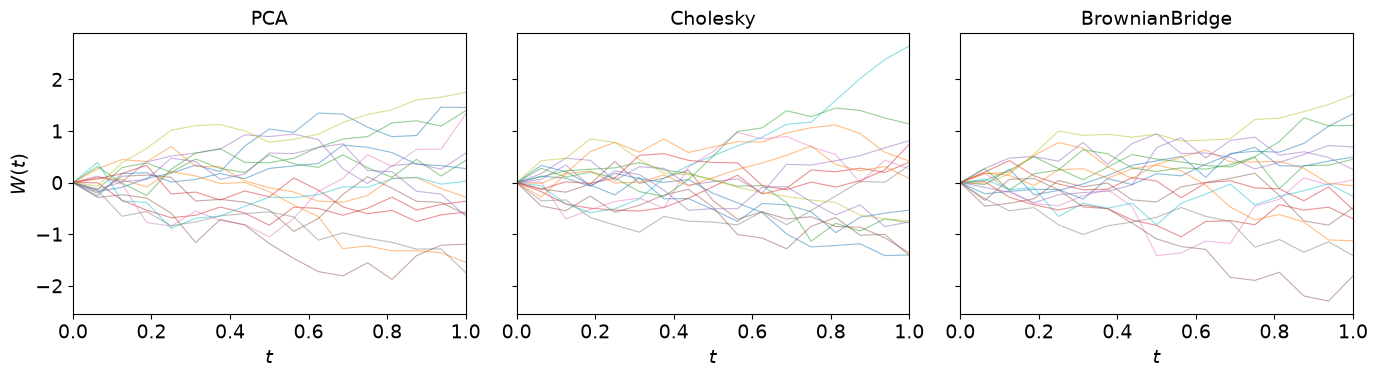

In [10]:
d = 16
n = 16
t_final = 1.0

fig, axes = pyplot.subplots(1, 3, figsize=(14, 4), sharey=True)
for ax, decomp in zip(axes, ['PCA', 'Cholesky', 'BrownianBridge']):
    bm = BrownianMotion(DigitalNetB2(d, seed=7), t_final=t_final, decomp_type=decomp)
    paths = bm.gen_samples(n)
    time_vec = np.concatenate([[0], bm.time_vec])
    paths_with_origin = np.hstack([np.zeros((n, 1)), paths])
    for path in paths_with_origin:
        ax.plot(time_vec, path, alpha=0.5, linewidth=0.8)
    ax.set_title(decomp)
    ax.set_xlabel('$t$')
    ax.set_xlim(0, t_final)
axes[0].set_ylabel('$W(t)$')
pyplot.tight_layout()
pyplot.show()

## Timing

PCA and Cholesky both cost $O(d^3)$ to build their matrix. The Brownian Bridge skips that step, but its setup, finding each point's nearest neighbors, still costs $O(d^2)$. That cost is paid once, and is small next to the cost of generating points across many paths.

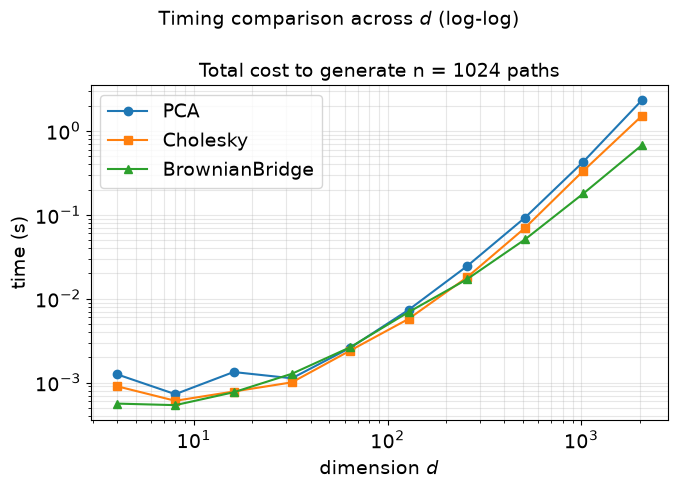

In [31]:
import time, warnings

ds = [4, 8, 16, 32, 64, 128, 256, 512, 1024, 2048]
n = 1024
methods = ['PCA', 'Cholesky', 'BrownianBridge']

def best_of(fn, repeats=3):
    best = float('inf')
    for _ in range(repeats):
        start = time.perf_counter()
        fn()
        best = min(best, time.perf_counter() - start)
    return best

def full_run(d, decomp, n):
    bm = BrownianMotion(DigitalNetB2(d, seed=7), decomp_type=decomp)
    bm.gen_samples(n)

total = {m: [] for m in methods}
for d in ds:
    for decomp in methods:
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            total[decomp].append(best_of(lambda: full_run(d, decomp, n)))

fig, ax = pyplot.subplots(figsize=(7, 5))
for decomp, marker in [('PCA', 'o-'), ('Cholesky', 's-'), ('BrownianBridge', '^-')]:
    ax.loglog(ds, total[decomp], marker, label=decomp)
ax.set_title(f'Total cost to generate n = {n} paths')
ax.set_xlabel('dimension $d$')
ax.set_ylabel('time (s)')
ax.grid(True, which='both', alpha=0.3)
ax.legend()
pyplot.suptitle('Timing comparison across $d$ (log-log)')
pyplot.tight_layout()
pyplot.show()

## Custom Monitoring Times

By default the sampling follows a van der Corput sequence. However, any set of distinct and positive times can be passed into `monitoring_times` with the order passed in being the sampling order. This makes it possible to prioritize specific time points by placing them earlier in the sampling order or concentrating more points across a specific window of time, which is relevant to barrier options.

In [12]:
bm = BrownianMotion(DigitalNetB2(4, seed=7),
                    decomp_type='BrownianBridge',
                    monitoring_times=[0.6, 1.0, 0.3, 0.8])
bm.time_vec, bm(2)

(array([0.3, 0.6, 0.8, 1. ]),
 array([[-0.42678211,  0.23976687,  0.19961117,  0.56330283],
        [-0.31994843, -1.22738085, -1.29415239, -1.73713917]]))

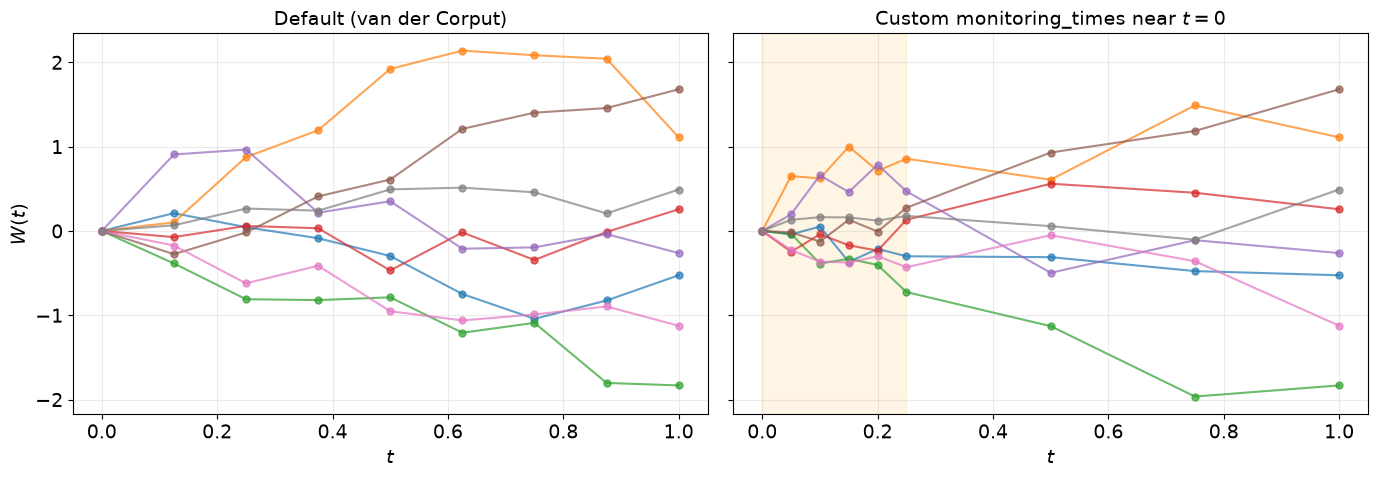

In [24]:
import warnings
d, n = 8, 8
custom = [1.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.5, 0.75]   # concentrated near t = 0 (front-end barrier)
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    bm_default = BrownianMotion(DigitalNetB2(d, seed=7), decomp_type='BrownianBridge')
    bm_custom = BrownianMotion(DigitalNetB2(d, seed=7), decomp_type='BrownianBridge',
                               monitoring_times=custom)
fig, axes = pyplot.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, bm, title in [(axes[0], bm_default, 'Default (van der Corput)'),
                      (axes[1], bm_custom, 'Custom monitoring_times near $t=0$')]:
    paths = bm.gen_samples(n)
    t = np.concatenate([[0.0], bm.time_vec])
    p = np.hstack([np.zeros((n, 1)), paths])
    for row in p:
        ax.plot(t, row, '-o', alpha=0.7, ms=5)
    ax.set_title(title)
    ax.set_xlabel('$t$')
    ax.grid(alpha=0.25)
axes[1].axvspan(0.0, 0.25, color='orange', alpha=0.1)
axes[0].set_ylabel('$W(t)$')
pyplot.tight_layout()
pyplot.show()

## Option Pricing

An Asian call option priced under each `decomp_type`:

In [14]:
d = 16        # monitoring dates
n = 2**10     # QMC samples
vol = 0.2     # volatility
S0 = 100.0    # initial stock price
K = 100.0     # strike price
r = 0.05      # risk-free rate
t_final = 1.0 # time horizon (years)

In [15]:
print(f"{'decomp_type':<16}  {'price':>8}")
print('-' * 28)
for decomp in ['PCA', 'Cholesky', 'BrownianBridge']:
    option = FinancialOption(
        DigitalNetB2(d, seed=7),
        option='ASIAN',
        volatility=vol,
        start_price=S0,
        strike_price=K,
        interest_rate=r,
        t_final=t_final,
        call_put='call',
        asian_mean='arithmetic',
        decomp_type=decomp,
    )
    print(f"{decomp:<16}  {option(n).mean():>8.4f}")

decomp_type          price
----------------------------
PCA                 5.7618
Cholesky            5.7432
BrownianBridge      5.7497


## References

<a id="ref1"></a>
[1] Owen, A. B. Monte Carlo theory, methods and examples. Section 5.2 (multivariate normal sampling, equations 5.3 and 5.4) and Section 6.4 (Brownian bridge, Algorithm 6.1, equations 6.10 and 6.11). https://artowen.su.domains/mc/

<a id="ref2"></a>
[2] Caflisch, R.E., Morokoff, W., and Owen, A.B. (1997). "Valuation of mortgage-backed securities using Brownian bridges to reduce effective dimension." Journal of Computational Finance, 1(1), 27–46.

<a id="ref3"></a>
[3] Glasserman, P. (2004). Monte Carlo Methods in Financial Engineering. Springer, New York. pp. 82–92.

<a id="ref4"></a>
[4] Lin, J. and Wang, X. (2008). "New Brownian bridge construction in quasi-Monte Carlo methods for computational finance." Journal of Complexity, 24(2), 109–133.